In [1]:
import os
import warnings
import pandas as pd
import features as f
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import statistics
warnings.filterwarnings('ignore')

In [2]:
parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\CleanBert_AdjustedWeights.csv")
embeddings = pd.read_csv(parent+"\\semantics\\fasttext-static_words.csv")

similarity = pd.read_csv(parent+"\\semantics\\fasttext-static_similarity.csv")
similarity.set_index("Unnamed: 0", inplace=True)
similarity.index.name = None

f.set_embedding_space(similarity = similarity, embeddings = embeddings)

In [3]:
data["Hit"] = data["Hit"].replace(2, 0)
df = f.apply_join(df_main =data.copy(), function = f.bert_find_most_similiar,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.bert_avg_sim_previous, n = 2,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.bert_contrast,
            groupby_groups=["Participant ID", "Participant Group", "ListID"], 
            n = 2)
df = f.apply_join(df_main=df.copy(), function = f.bert_sim_last_word,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.position_zone,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.bert_stm_max_sim_n, n = 2,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.bert_stm_cumulative_semantic_density, n = 4,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])

In [4]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,ListID,Presented Word,Present Position,Recalled Word,Recall Position,Reaction Time,Hit,Participant ID,Participant Group,PID,...,MOST_SIM_DIST,DEBUG_MOST_SIM_POS,AVG_SIM_PREV_2,AVG_CONTRAST_2,PREV_SIM,PRESENT_ZONE,STM_MAX_SIM,STM_MAX_SIM_DIST,STM_MAX_SIM_POS,STM_SEMANTIC_D
0,0,MASA,1,masa,1.0,4.486727,1,9,soc,9soc,...,NaN,NaN,NaN,0.916456,NaN,1,1.000000,0,0,0.000000
1,0,CAM,2,cam,3.0,1.818692,1,9,soc,9soc,...,1.0,0.0,0.926249,0.938122,0.926249,1,0.926249,1,0,0.000000
2,0,SU,3,su,2.0,2.266246,1,9,soc,9soc,...,1.0,1.0,0.900715,0.941793,0.925368,1,0.925368,1,1,0.926249
3,0,İYİLİK,4,iyilik,4.0,2.599360,1,9,soc,9soc,...,1.0,2.0,0.856065,0.931392,0.880317,1,0.880317,1,2,2.727679
4,0,TÜTÜN,5,tütün,5.0,2.284987,1,9,soc,9soc,...,1.0,3.0,0.906927,0.942771,0.937716,2,0.937716,1,3,5.265138


In [5]:
df = df.drop("BERT", axis=1)

Mean for Group 1 : 0.325 | Mean for Group 0 : 0.330
Std for Group 1 : 0.080 | Std for Group 0 : 0.080

Mean for Group 1 : 0.328 | Mean for Group 0 : 0.332
Std for Group 1 : 0.062 | Std for Group 0 : 0.063

Mean for Group 1 : 0.330 | Mean for Group 0 : 0.331
Std for Group 1 : 0.056 | Std for Group 0 : 0.057

Mean for Group 1 : 0.329 | Mean for Group 0 : 0.332
Std for Group 1 : 0.054 | Std for Group 0 : 0.056



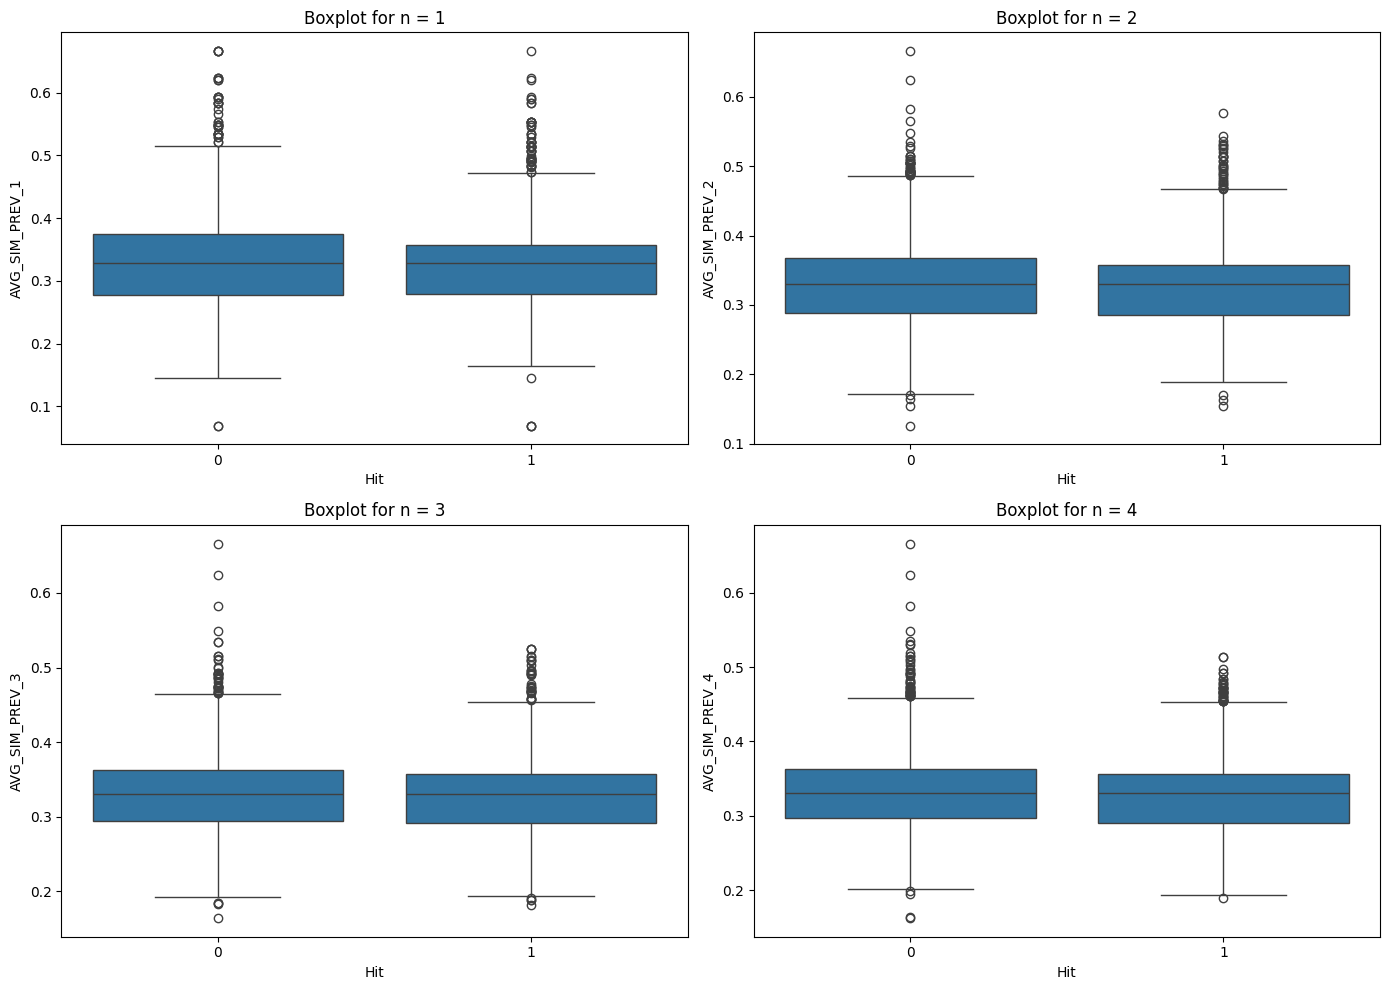

In [6]:
#n tuning for avg_sim_prev function
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  

for i in range(4):
    n = i+1
    tune_n_custom = f.apply_join(
        df_main=data.copy(), 
        function=f.avg_sim_previous, 
        n=n,
        groupby_groups=["Participant ID", "Participant Group", "ListID"]
    )
    
    col_name = f"AVG_SIM_PREV_{n}"
    tune_n_custom[col_name].fillna(tune_n_custom[col_name].mean(), inplace=True)
    
    sns.boxplot(data=tune_n_custom, x="Hit", y=col_name, ax=axes[i])
    axes[i].set_title(f"Boxplot for n = {n}")

    mean1 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    mean0 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    sd1 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    sd0 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    print(f"Mean for Group 1 : {mean1:.3f} | Mean for Group 0 : {mean0:.3f}")
    print(f"Std for Group 1 : {sd1:.3f} | Std for Group 0 : {sd0:.3f}\n")

plt.tight_layout()
plt.show()

In [7]:
df = df[df["ListID"]!=0]
df = df.drop(["Recalled Word", "Recall Position","Reaction Time","DEBUG_MOST_SIM_POS"], axis = 1)
df["P_ID"] = df["Participant Group"].astype(str)+df["Participant ID"].astype(str)
df = df.drop(["Participant ID"], axis = 1)
df.columns = [col.upper() for col in df.columns]
df.columns = [col.replace(" ", "_") for col in df.columns]
df.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,PID,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_2,PREV_SIM,PRESENT_ZONE,STM_MAX_SIM,STM_MAX_SIM_DIST,STM_MAX_SIM_POS,STM_SEMANTIC_D,P_ID
6,1,KALEM,1,1,soc,9soc,NaN,NaN,NaN,0.927263,NaN,1,1.000000,0,0,0.000000,soc9
7,1,ÖLÇEK,2,0,soc,9soc,0.919238,1.0,0.919238,0.947726,0.919238,1,0.919238,1,0,0.000000,soc9
8,1,ÇANTA,3,0,soc,9soc,0.918549,1.0,0.909100,0.957456,0.918549,1,0.918549,1,1,0.919238,soc9
9,1,AĞAÇ,4,1,soc,9soc,0.959891,1.0,0.946034,0.974355,0.959891,1,0.959891,1,2,2.737437,soc9
10,1,PARK,5,0,soc,9soc,0.952051,1.0,0.939871,0.964566,0.952051,2,0.952051,1,3,5.537444,soc9


<Axes: ylabel='Count'>

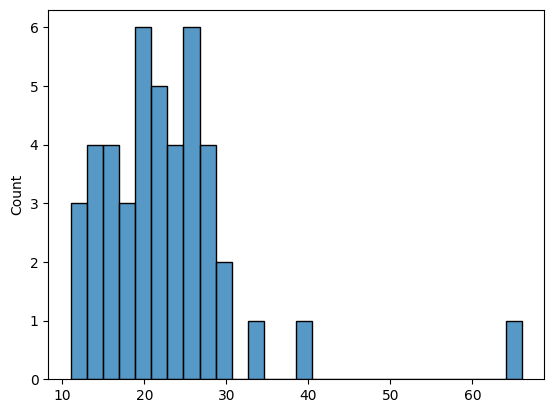

In [8]:
participant_hits = df.groupby(by="P_ID")["HIT"].apply(sum)
sns.histplot(participant_hits.values, binwidth=2)

In [9]:
df.columns

Index(['LISTID', 'PRESENTED_WORD', 'PRESENT_POSITION', 'HIT',
       'PARTICIPANT_GROUP', 'PID', 'MOST_SIM_VAL', 'MOST_SIM_DIST',
       'AVG_SIM_PREV_2', 'AVG_CONTRAST_2', 'PREV_SIM', 'PRESENT_ZONE',
       'STM_MAX_SIM', 'STM_MAX_SIM_DIST', 'STM_MAX_SIM_POS', 'STM_SEMANTIC_D',
       'P_ID'],
      dtype='object')

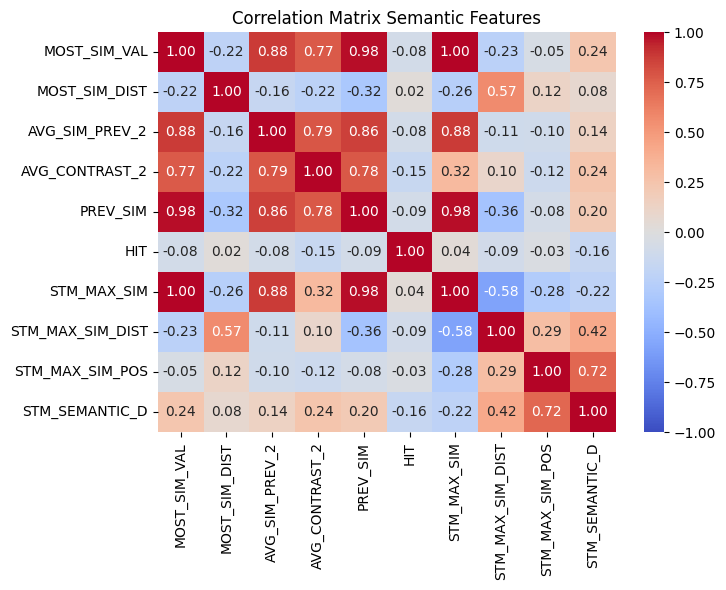

In [10]:
corr_matrix = df[["MOST_SIM_VAL", "MOST_SIM_DIST", "AVG_SIM_PREV_2",
                  "AVG_CONTRAST_2","PREV_SIM", "HIT", 'STM_MAX_SIM', 'STM_MAX_SIM_DIST', 'STM_MAX_SIM_POS', 'STM_SEMANTIC_D']].corr()

plt.figure(figsize=(7.5, 6))
# A diverging colormap (coolwarm) makes strong negative and positive correlations pop out
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix Semantic Features")
plt.tight_layout()
plt.show()

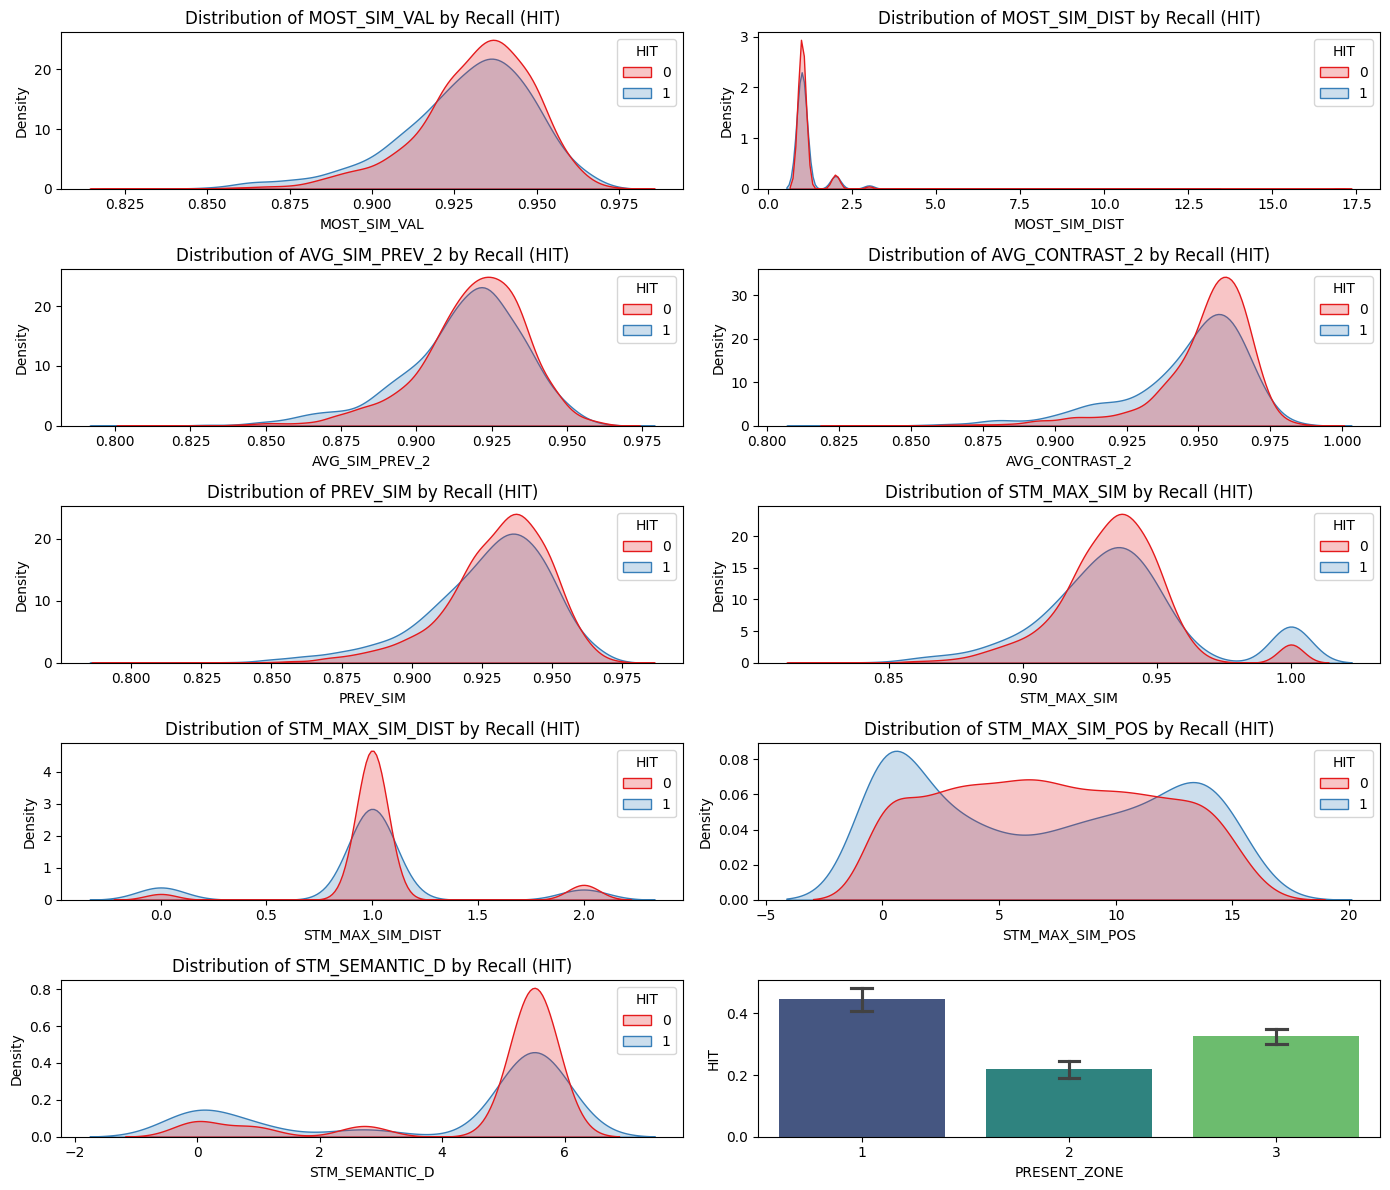

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 12))
axes = axes.flatten()
features_to_plot = ["MOST_SIM_VAL", "MOST_SIM_DIST", "AVG_SIM_PREV_2","AVG_CONTRAST_2","PREV_SIM", 'STM_MAX_SIM', 'STM_MAX_SIM_DIST', 'STM_MAX_SIM_POS', 'STM_SEMANTIC_D']
for i, feature in enumerate(features_to_plot):
    # sns.kdeplot normalizes the density, making the 70/30 imbalance irrelevant visually
    sns.kdeplot(data=df, x=feature, hue="HIT", common_norm=False, fill=True, ax=axes[i], palette="Set1")
    axes[i].set_title(f"Distribution of {feature} by Recall (HIT)")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

sns.barplot(data=df, x='PRESENT_ZONE', y='HIT', palette='viridis', capsize=0.1)
plt.tight_layout()
plt.show()

<Axes: xlabel='STM_MAX_SIM_POS', ylabel='Count'>

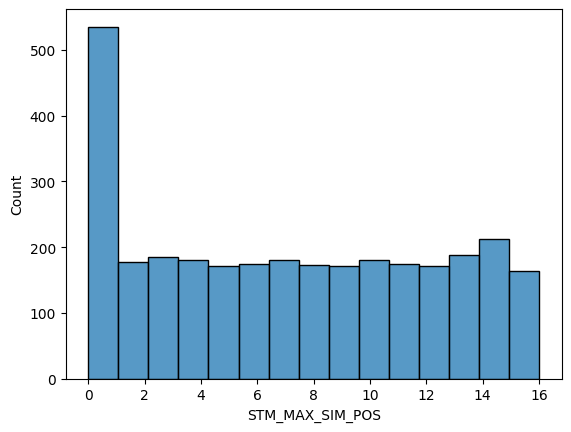

In [16]:
sns.histplot(df["STM_MAX_SIM_POS"])

In [12]:
df.to_csv(parent+"\\data\\MEM_Features_01_BERT.csv")